## Pull BigQuery Dataset:

In [1]:
# ============================================================
# Cell 1: Imports, Auth, Config
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.oauth2 import service_account
from google.cloud import bigquery

# ── Styling ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Config ───────────────────────────────────────────────────
PROJECT_ID = "recosys-489001"
DATASET_ID = "recosys"
TABLE_ID   = "events_raw"
TABLE_REF  = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"
KEY_PATH   = os.path.expanduser("C:\\Users\\Patron\\Documents\\GitHub\\RecoSys\\secrets\\recosys-service-account.json")

# ── Auth ─────────────────────────────────────────────────────
credentials = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print(f"✅ Connected — {credentials.service_account_email}")

✅ Connected — 921967012784-compute@developer.gserviceaccount.com


In [2]:
# ============================================================
# Cell 2: Query Helper
# ============================================================
import time

# Simple in-memory cache so re-running cells doesn't re-bill you
_cache = {}

def run_query(sql: str, label: str = "", use_cache: bool = True) -> pd.DataFrame:
    """
    Run a BigQuery SQL query and return a DataFrame.
    
    - Dry-runs first to print bytes that will be scanned.
    - Caches results in memory by label (set use_cache=False to force refresh).
    - Prints elapsed time on completion.
    """
    cache_key = label or sql[:120]
    
    if use_cache and cache_key in _cache:
        df = _cache[cache_key]
        print(f"[cache] '{label}' → {len(df):,} rows")
        return df

    # ── Dry run: estimate cost before executing ──────────────
    dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    dry_job = bq.query(sql, job_config=dry_config)
    bytes_scanned = dry_job.total_bytes_processed
    gb_scanned    = bytes_scanned / 1e9
    cost_est      = (bytes_scanned / 1e12) * 5  # $5 per TB

    print(f"{'─'*60}")
    if label:
        print(f"  Query  : {label}")
    print(f"  Scan   : {gb_scanned:.2f} GB  (~${cost_est:.4f})")
    
    # Warn but don't block — you decide whether to proceed
    if gb_scanned > 10:
        print(f"  ⚠️  Large scan — confirm this is intentional")

    # ── Execute ──────────────────────────────────────────────
    t0  = time.time()
    job = bq.query(sql)
    df  = job.result().to_dataframe()
    elapsed = time.time() - t0

    print(f"  Rows   : {len(df):,}")
    print(f"  Time   : {elapsed:.1f}s")
    print(f"{'─'*60}")

    if label:
        _cache[cache_key] = df
    return df


def clear_cache():
    _cache.clear()
    print("Cache cleared.")

In [3]:
# ============================================================
# Cell 3: Table metadata — zero cost
# ============================================================
table = bq.get_table(TABLE_REF)
print(f"Table      : {table.full_table_id}")
print(f"Rows       : {table.num_rows:,}")
print(f"Size       : {table.num_bytes/1e9:.2f} GB")
print(f"Created    : {table.created}")
print(f"Modified   : {table.modified}")
print(f"\nSchema:")
for f in table.schema:
    nullable = "NULLABLE" if f.is_nullable else "REQUIRED"
    print(f"  {f.name:<20} {f.field_type:<12} {nullable}")

Table      : recosys-489001:recosys.events_raw
Rows       : 411,709,736
Size       : 45.94 GB
Created    : 2026-03-04 00:34:11.354000+00:00
Modified   : 2026-03-04 00:34:11.354000+00:00

Schema:
  event_time           TIMESTAMP    NULLABLE
  event_type           STRING       NULLABLE
  product_id           INTEGER      NULLABLE
  category_id          INTEGER      NULLABLE
  category_code        STRING       NULLABLE
  brand                STRING       NULLABLE
  price                FLOAT        NULLABLE
  user_id              INTEGER      NULLABLE
  user_session         STRING       NULLABLE


## BigQuery EDA

In [4]:
# ============================================================
# AREA 0: Monthly Volume Breakdown
# DETERMINISTIC — no thresholds needed
# PURPOSE: Confirm all 7 months loaded correctly, see growth
#          trends, event mix per month
# ============================================================
sql_area0 = f"""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', event_time)         AS month,
  COUNT(*)                                       AS total_events,
  COUNT(DISTINCT user_id)                        AS unique_users,
  COUNT(DISTINCT product_id)                     AS unique_products,
  COUNTIF(event_type = 'view')                   AS views,
  COUNTIF(event_type = 'cart')                   AS carts,
  COUNTIF(event_type = 'purchase')               AS purchases,
  ROUND(COUNTIF(event_type = 'cart')
        / COUNT(*) * 100, 2)                     AS cart_rate_pct,
  ROUND(COUNTIF(event_type = 'purchase')
        / COUNT(*) * 100, 2)                     AS purchase_rate_pct
FROM `{TABLE_REF}`
GROUP BY month
ORDER BY month
"""
df_area0 = run_query(sql_area0, label="area0_monthly_volume")
df_area0

────────────────────────────────────────────────────────────
  Query  : area0_monthly_volume
  Scan   : 12.38 GB  (~$0.0619)
  ⚠️  Large scan — confirm this is intentional


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 7
  Time   : 0.8s
────────────────────────────────────────────────────────────


,month,total_events,unique_users,unique_products,views,carts,purchases,cart_rate_pct,purchase_rate_pct
0,2019-10,42448764,3022290,166794,40779399,926516,742849,2.18,1.75
1,2019-11,67501979,3696117,190662,63556110,3028930,916939,4.49,1.36
2,2019-12,67542878,4577232,205230,62986067,3394763,1162048,5.03,1.72
3,2020-01,55967041,4385985,227608,52490785,2641249,835007,4.72,1.49
4,2020-02,55318565,4233206,258469,51232669,2885608,1200288,5.22,2.17
5,2020-03,56341241,4114060,263383,52347910,2968397,1024934,5.27,1.82
6,2020-04,66589268,4509623,263503,62353909,3268600,966759,4.91,1.45


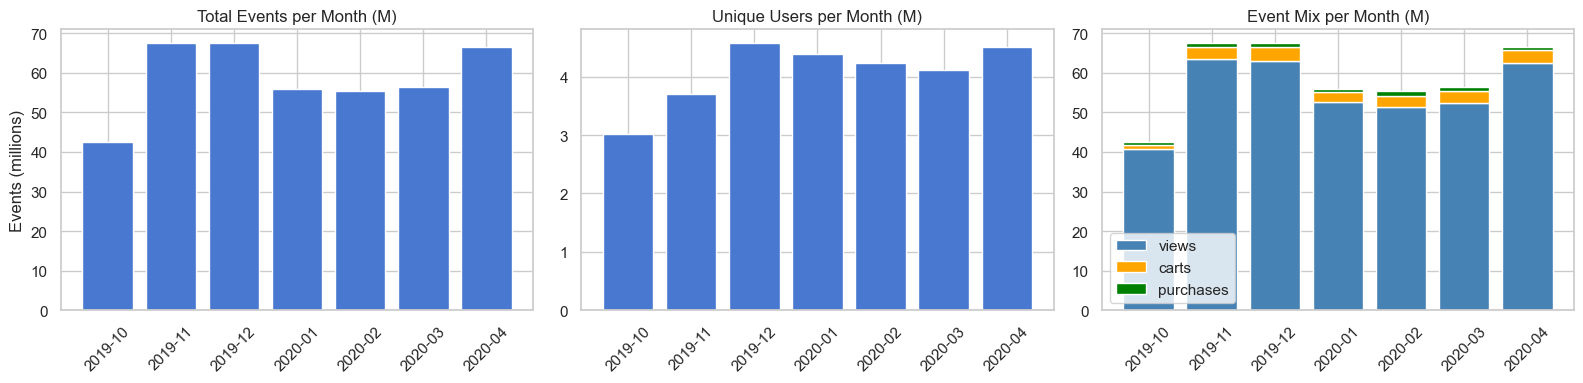

In [5]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(df_area0["month"], df_area0["total_events"] / 1e6)
axes[0].set_title("Total Events per Month (M)")
axes[0].set_ylabel("Events (millions)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(df_area0["month"], df_area0["unique_users"] / 1e6)
axes[1].set_title("Unique Users per Month (M)")
axes[1].tick_params(axis="x", rotation=45)

bottom = [0] * len(df_area0)
for event, color in [("views","steelblue"), ("carts","orange"), ("purchases","green")]:
    axes[2].bar(df_area0["month"], df_area0[event] / 1e6,
                bottom=bottom, label=event, color=color)
    bottom = [b + v for b, v in zip(bottom, df_area0[event] / 1e6)]
axes[2].set_title("Event Mix per Month (M)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# AREA 1: Null & Completeness Audit
# DETERMINISTIC — exact null counts, no thresholds
# PURPOSE: Know exact null % per column; decide handling
#          strategy for category_code, brand, price nulls
# ============================================================
sql_area1 = f"""
SELECT
  COUNT(*)                                            AS total_rows,

  -- Nulls per column
  COUNTIF(event_time    IS NULL)                      AS null_event_time,
  COUNTIF(event_type    IS NULL)                      AS null_event_type,
  COUNTIF(product_id    IS NULL)                      AS null_product_id,
  COUNTIF(category_id   IS NULL)                      AS null_category_id,
  COUNTIF(category_code IS NULL)                      AS null_category_code,
  COUNTIF(brand         IS NULL)                      AS null_brand,
  COUNTIF(price         IS NULL)                      AS null_price,
  COUNTIF(user_id       IS NULL)                      AS null_user_id,
  COUNTIF(user_session  IS NULL)                      AS null_user_session,

  -- Null % per column
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2) AS pct_null_category_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2) AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2) AS pct_null_price,
  ROUND(COUNTIF(user_session IS NULL)  / COUNT(*) * 100, 2) AS pct_null_user_session,

  -- Are nulls in category_code and brand correlated?
  COUNTIF(category_code IS NULL AND brand IS NULL)    AS null_both_cat_brand,
  COUNTIF(category_code IS NULL AND brand IS NOT NULL) AS null_cat_only,
  COUNTIF(category_code IS NOT NULL AND brand IS NULL) AS null_brand_only
FROM `{TABLE_REF}`
"""
df_area1 = run_query(sql_area1, label="area1_nulls")
df_area1.T  # transpose for readability

────────────────────────────────────────────────────────────
  Query  : area1_nulls
  Scan   : 45.94 GB  (~$0.2297)
  ⚠️  Large scan — confirm this is intentional


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 1
  Time   : 1.4s
────────────────────────────────────────────────────────────


,0
total_rows,411709736
null_event_time,0
null_event_type,0
null_product_id,0
null_category_id,0
null_category_code,65171763
null_brand,55670767
null_price,0
null_user_id,0
null_user_session,226


In [7]:
# ── Are nulls concentrated in specific event types? ─────────
sql_area1b = f"""
SELECT
  event_type,
  COUNT(*)                                                    AS total,
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2)  AS pct_null_cat_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_price
FROM `{TABLE_REF}`
GROUP BY event_type
ORDER BY total DESC
"""
df_area1b = run_query(sql_area1b, label="area1_nulls_by_event_type")
df_area1b

────────────────────────────────────────────────────────────
  Query  : area1_nulls_by_event_type
  Scan   : 17.12 GB  (~$0.0856)
  ⚠️  Large scan — confirm this is intentional


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 3
  Time   : 0.9s
────────────────────────────────────────────────────────────


,event_type,total,pct_null_cat_code,pct_null_brand,pct_null_price
0,view,385746849,16.10,13.88,0.00
1,cart,19114063,12.02,8.40,0.00
2,purchase,6848824,11.21,7.71,0.00


In [8]:
# ============================================================
# AREA 2: Duplicate Detection
# DETERMINISTIC — exact counts, no thresholds
# PURPOSE: Find exact dupes AND near-dupes (same user+product+
#          event within a short time window)
# ============================================================

# ── Exact duplicates (all 9 columns identical) ──────────────
sql_area2_exact = f"""
SELECT
  COUNT(*)                              AS total_rows,
  COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))                                  AS exact_duplicate_rows,
  ROUND((COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))) / COUNT(*) * 100, 4)            AS exact_dupe_pct
FROM `{TABLE_REF}`
"""
df_area2_exact = run_query(sql_area2_exact, label="area2_exact_dupes")
df_area2_exact

────────────────────────────────────────────────────────────
  Query  : area2_exact_dupes
  Scan   : 28.02 GB  (~$0.1401)
  ⚠️  Large scan — confirm this is intentional


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 1
  Time   : 6.6s
────────────────────────────────────────────────────────────


,total_rows,exact_duplicate_rows,exact_dupe_pct
0,411709736,1384436,0.34


In [9]:
# ============================================================
# AREA 3: Price Distribution & Outlier Analysis
# DETERMINISTIC — percentiles give you the data to decide;
#                 actual cutoff is a TODO after seeing numbers
# PURPOSE: Set price floor and ceiling for cleaning
# ============================================================

# ── Percentile distribution ──────────────────────────────────
sql_area3_pct = f"""
SELECT
  MIN(price)                                      AS price_min,
  MAX(price)                                      AS price_max,
  AVG(price)                                      AS price_mean,
  APPROX_QUANTILES(price, 100)[OFFSET(1)]         AS p1,
  APPROX_QUANTILES(price, 100)[OFFSET(5)]         AS p5,
  APPROX_QUANTILES(price, 100)[OFFSET(25)]        AS p25,
  APPROX_QUANTILES(price, 100)[OFFSET(50)]        AS p50,
  APPROX_QUANTILES(price, 100)[OFFSET(75)]        AS p75,
  APPROX_QUANTILES(price, 100)[OFFSET(90)]        AS p90,
  APPROX_QUANTILES(price, 100)[OFFSET(95)]        AS p95,
  APPROX_QUANTILES(price, 100)[OFFSET(99)]        AS p99,
  APPROX_QUANTILES(price, 100)[OFFSET(100)]       AS p100,
  COUNTIF(price IS NULL)                          AS null_price_count,
  COUNTIF(price <= 0)                             AS zero_or_negative_price,
  COUNTIF(price > 10000)                          AS price_gt_10k,
  COUNTIF(price > 50000)                          AS price_gt_50k
FROM `{TABLE_REF}`
"""
df_area3_pct = run_query(sql_area3_pct, label="area3_price_percentiles")
df_area3_pct.T

────────────────────────────────────────────────────────────
  Query  : area3_price_percentiles
  Scan   : 3.29 GB  (~$0.0165)
  Rows   : 1
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
price_min,0.00
price_max,"2,574.07"
price_mean,285.46
p1,5.12
p5,14.41
p25,62.04
p50,161.65
p75,349.82
p90,742.73
p95,991.02


In [10]:
# ── Price bucket distribution (log-scale histogram proxy) ───
sql_area3_buckets = f"""
SELECT
  CASE
    WHEN price IS NULL       THEN 'NULL'
    WHEN price <= 0          THEN '<=0'
    WHEN price < 1           THEN '0-1'
    WHEN price < 10          THEN '1-10'
    WHEN price < 50          THEN '10-50'
    WHEN price < 100         THEN '50-100'
    WHEN price < 500         THEN '100-500'
    WHEN price < 1000        THEN '500-1k'
    WHEN price < 5000        THEN '1k-5k'
    WHEN price < 10000       THEN '5k-10k'
    ELSE '>10k'
  END                        AS price_bucket,
  COUNT(*)                   AS event_count,
  COUNT(DISTINCT product_id) AS unique_products
FROM `{TABLE_REF}`
GROUP BY price_bucket
ORDER BY MIN(IFNULL(price, -1))
"""
df_area3_buckets = run_query(sql_area3_buckets, label="area3_price_buckets")
df_area3_buckets

────────────────────────────────────────────────────────────
  Query  : area3_price_buckets
  Scan   : 6.59 GB  (~$0.0329)


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 8
  Time   : 1.6s
────────────────────────────────────────────────────────────


,price_bucket,event_count,unique_products
0,<=0,714465,90310
1,0-1,94811,1453
2,1-10,12211495,61392
3,10-50,71715928,133113
4,50-100,62150148,84373
5,100-500,196417948,114727
6,500-1k,48118909,21695
7,1k-5k,20286032,10149


In [11]:
# TODO — AFTER SEEING RESULTS:
# Set these two thresholds based on percentile output above:
#   PRICE_FLOOR   = ???   # likely 0 or a small positive value
#   PRICE_CEILING = ???   # look at p99 vs p100 gap — that gap tells you
#                         # whether there are extreme outliers worth capping
# Common approach: keep prices between p0.5 and p99.5, or use a
# domain-based ceiling (e.g., $10,000 for eCommerce makes sense).
# Document your decision in docs/eda_findings.md